In [1]:
import jax
import jax.random as jrandom
import jax.tree_util as jtu
import jax.numpy as jnp
from jax import lax

from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, Tsit5, VirtualBrownianTree, STLAControlTerm, STLAMultiTerm, SEA, ShARK, PIDController, LevyVal, ALIGN

import diffrax
import math
import matplotlib.pyplot as plt

from diffrax.solver.ansr import StochasticButcherTableau


def plot_sol(sol):
    plt.plot(sol.ts, sol.ys[:,0], label="x1")
    plt.plot(sol.ts, sol.ys[:,1], label="x2")
    plt.plot(sol.ts, sol.ys[:,2], label="v1")
    plt.plot(sol.ts, sol.ys[:,3], label="v2")
    plt.legend()
    plt.show()

In [2]:
def drift(t, y, args):
    gamma, u, grad_f = args
    x, v = y[:2], y[2:]
    d_x = v
    d_v = -gamma * v - u * grad_f(x)
    d_y = jnp.array([d_x, d_v], dtype=jnp.float32).flatten()
    return d_y

def diffusion(t, y, args):
    gamma, u, _ = args
    d_v = jnp.sqrt(2*gamma*u) * jnp.ones((2,), dtype=y.dtype)
    d_y = jnp.concatenate((jnp.zeros((2,2), dtype=jnp.float32), jnp.diag(d_v)), axis=0)
    return d_y

t0, t1 = 0.3, 15
bm1 = VirtualBrownianTree(t0, t1, tol=2**-8, shape=(2,), key=jrandom.PRNGKey(2), compute_stla=True)
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, bm1))
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
args = (0.3, 5.0, lambda x: x)
y0=jnp.array([0, 0, 0, 0], dtype=jnp.float32)

recomputing coeffs for h = 0.09999999403953552
recomputing coeffs for h = 0.09997940063476562


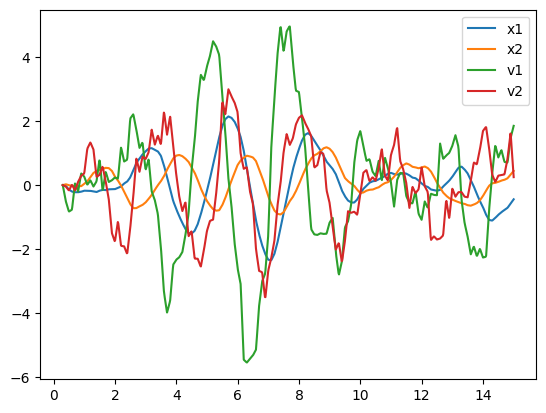

In [3]:
solALIGN = diffeqsolve(terms, ALIGN(), t0, t1, dt0=0.1, y0=y0, args=args, saveat=saveat)
plot_sol(solALIGN)

recomputing coeffs for h = 0.009999990463256836
recomputing coeffs for h = 0.010000109672546387
recomputing coeffs for h = 0.009999990463256836
recomputing coeffs for h = 0.010000228881835938
recomputing coeffs for h = 0.009999752044677734
recomputing coeffs for h = 0.010000228881835938
recomputing coeffs for h = 0.009752273559570312


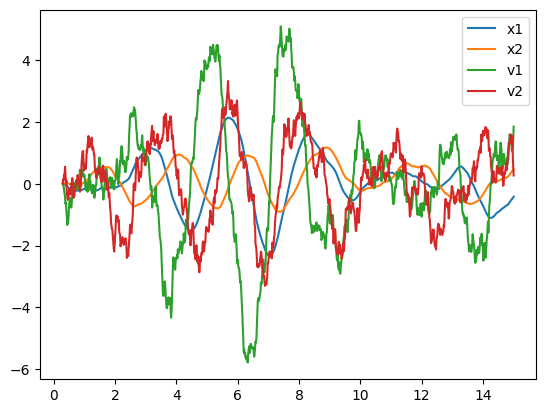

In [4]:
solALIGN2 = diffeqsolve(terms, ALIGN(), t0, t1, dt0=0.01, y0=y0, args=args, saveat=saveat)
plot_sol(solALIGN2)

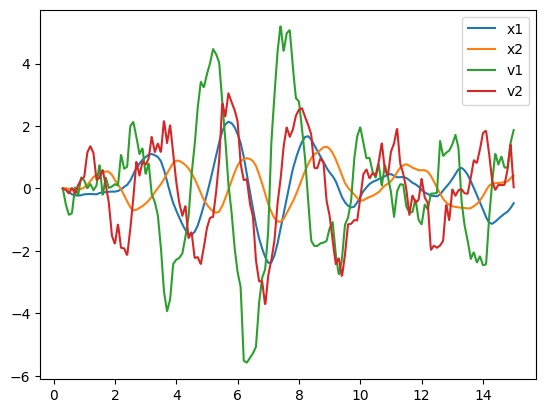

In [5]:
solSRK = diffeqsolve(terms, ShARK(), t0, t1, dt0=0.1, y0=y0, args=args, saveat=saveat)
plot_sol(solSRK)

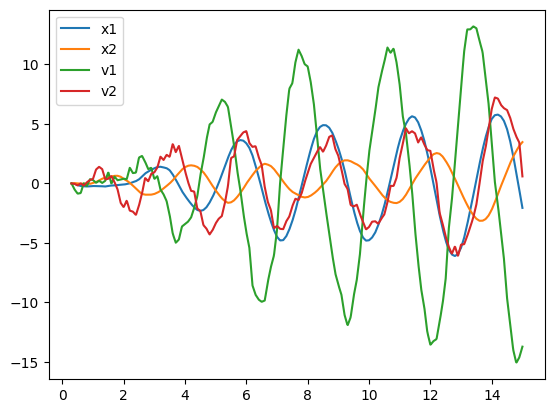

In [6]:
solSE = diffeqsolve(terms, SEA(), t0, t1, dt0=0.1, y0=y0, args=args, saveat=saveat)
plot_sol(solSE)

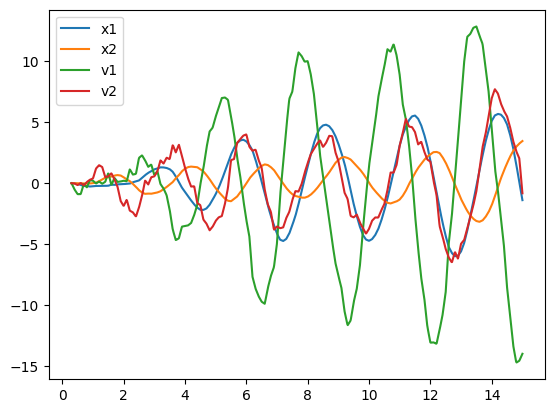

In [7]:
solEuler = diffeqsolve(terms, Euler(), t0, t1, dt0=0.1, y0=y0, args=args,
                    saveat=saveat)
plot_sol(solEuler)

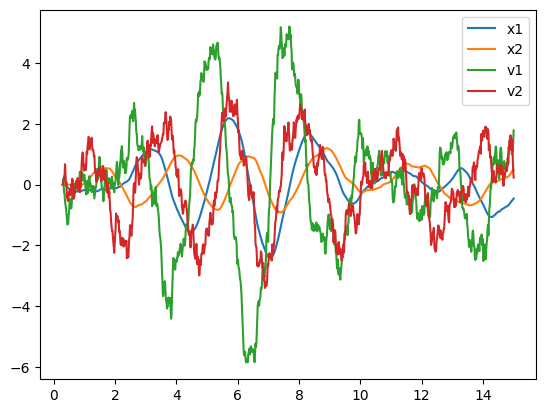

In [8]:
solPrecise = diffeqsolve(terms, Euler(), t0, t1, dt0=0.005, y0=y0, args=args,
                    saveat=saveat)
plot_sol(solPrecise)

In [10]:
print(f"Euler:    {solEuler.ys[-1]}")
print(f"SEA:      {solSE.ys[-1]}")
print(f"ShARK:    {solSRK.ys[-1]}")
print(f"ALIGN     {solALIGN.ys[-1]}")
print(f"ALIGN2    {solALIGN2.ys[-1]}")
print(f"Precise:  {solPrecise.ys[-1]}")

Euler:    [ -1.3888756    3.4521713  -13.969547    -0.82664895]
SEA:      [ -2.056066     3.4724042  -13.721716     0.59029317]
ShARK:    [-0.47123247  0.41051543  1.8700808   0.03999829]
ALIGN     [-0.36375266  0.44941404  1.9636188   0.14390528]
ALIGN2    [-0.41966474  0.45386624  1.8461541   0.26572567]
Precise:  [-0.45867127  0.48229048  1.783628    0.23091099]
